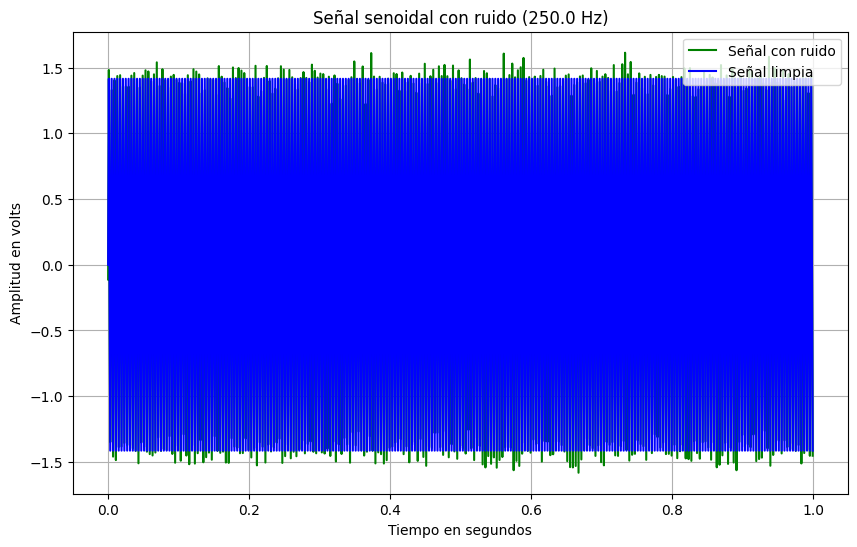

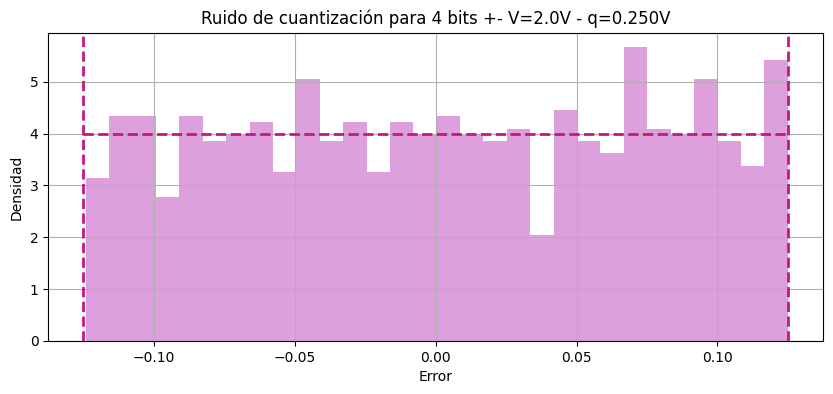

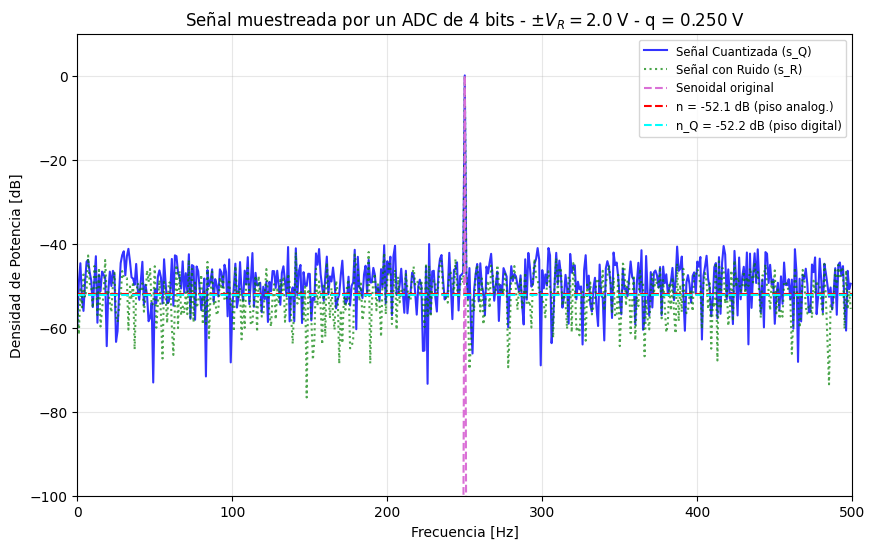

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Función para generar la señal senoidal.
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx

# Parámetros de la senoidal
vmax = np.sqrt(2)  # energía unitaria
dc = 0
nn = 1000          # número de muestras
fs = nn            # frecuencia de muestreo según la consigna.

# --- CAMBIO MARIANO: k = N/4 ---
# ff = 250 Hz hará que en 1000 muestras haya 250 ciclos exactos (k=250)
ff = nn / 4

# Señal senoidal limpia.
tt, xx = mi_funcion_sen(vmax, dc, ff, ph=0, nn=nn, fs=fs)

# %% Parámetros del ADC para calcular la potencia de cuantización
B = 4              # bits
VF = 2             # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)  # paso de cuantización
Pq = q**2 / 12     # potencia de cuantización
kn = 1             # factor de escala del ruido
Pn = kn * Pq       # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido    # Defino la señal con ruido.

# %% Gráfico comparativo (Aquí se verá la "mancha" de los 250 ciclos como querías)
plt.figure(figsize=(10, 6))
plt.plot(tt, yy, color='GREEN', label='Señal con ruido')
plt.plot(tt, xx, color='BLUE', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# %% ERROR
# yyq es la señal sr_quant (señal ruidosa cuantizada)
yyq = np.round(yy / q) * q
yyq = np.clip(yyq, -VF, VF - q)

ee = yyq - yy  # error sobre señal con ruido
plt.figure(figsize=(10, 4))
plt.hist(ee, bins=30, color='plum', density=True) # Aumenté los bins para que se vea mejor

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)

# Línea superior, que representa la distribución uniforme ideal.
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title(f"Ruido de cuantización para {B} bits +- V={VF}.0V - q={q:.3f}V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# --- Calculo las FFT de las tres señales para luego hacer la comparación ---
fft_x = np.fft.fft(xx)   # Senoidal limpia
fft_y = np.fft.fft(yy)   # Senoidal más el ruido Gaussiano
fft_yq = np.fft.fft(yyq) # Senoidal más el ruido Gaussiano más el ruido de cuantización

# Calculo las Frecuencias, pero solo la parte positiva debido a que las negativas carecen de sentido físico.
freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

# Calculo el espectro de potencia normalizado para que el pico sea en 0 dB
def calculardens(f_data, n):
    # La densidad de potencia se calcula como (1/N^2) * |FFT|^2
    dens = (1/n**2) * np.abs(f_data)**2
    
    # Multiplicamos por 2 la parte positiva para mantener la energía (Single-sided spectrum)
    # Excepto en DC (0) y Nyquist (-1)
    dens[1:-1] *= 2 
    
    # Retornamos en dB. El + 1e-12 evita el log(0)
    return 10 * np.log10(dens[mask] + 1e-12)

# Calcula cada densidad
calculardensxx = calculardens(fft_x, nn)
calculardensyy = calculardens(fft_y, nn)
calculardensyq = calculardens(fft_yq, nn)

# %% Hago el gráfico comparativo.
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada, que debería ser la de mayor ruido.
plt.plot(fpos, calculardensyq, color='BLUE', label='Señal Cuantizada (s_Q)', alpha=0.8)

# Grafico la densidad espectral de la señal con ruido.
plt.plot(fpos, calculardensyy, color='GREEN', label='Señal con Ruido (s_R)', linestyle=':', alpha=0.7)

# Grafico la senoidal original
plt.plot(fpos, calculardensxx, label='Senoidal original', linestyle='--', color='orchid')

# --- Cálculo de los Pisos de Ruido ---

# 1. Piso analógico: Promedio del ruido que ya traía la señal (rojo)
# Filtramos para promediar solo el ruido (lejos del pico de la señal)
piso_analogico = np.mean(calculardensyy[fpos > ff+5]) 
plt.axhline(piso_analogico, color='red', linestyle='--', linewidth=1.5, 
            label=f'n = {piso_analogico:.1f} dB (piso analog.)')

# 2. Piso digital: Calculamos el error de cuantización puro (cian)
fft_error_puro = np.fft.fft(yyq - yy)
dens_error_puro = calculardens(fft_error_puro, nn)
piso_digital = np.mean(dens_error_puro)

plt.axhline(piso_digital, color='cyan', linestyle='--', linewidth=1.5, 
            label=f'n_Q = {piso_digital:.1f} dB (piso digital)')

# --- Configuración final del gráfico ---
plt.title(f"Señal muestreada por un ADC de {B} bits - $\pm V_R = {VF}.0$ V - q = {q:.3f} V")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.ylim([-100, 10])
plt.xlim([0, fs/2])

# Estilo de leyenda idéntico al ejemplo
plt.legend(loc='upper right', fontsize='small', frameon=True)
plt.grid(True, alpha=0.3)
plt.show()